
# Project Introduction: Predicting Gold Recovery from Ore Processing  
The purpose of this project is to build a predictive model that estimates gold recovery efficiency during two stages of the ore processing pipeline: `rougher.output.recovery` (recovery rate at the flotation stage) and `final.output.recovery` (recovery rate after the final purification stage). Model performance will be evaluated using the symmetric Mean Absolute Percentage Error (sMAPE), a metric that accounts for the relative error between predicted and actual values.


Gold is extracted from ore through a two-stage process. First, in the flotation stage (known as the rougher process), the ore is processed in flotation banks with the aid of chemical reagents such as Xanthate (activator), Sulphate (sodium sulphide), and Depressant (sodium silicate). This separates the material into rougher concentrate (gold-enriched product) and rougher tails (waste with low gold content). Second, the rougher concentrate undergoes a two-step purification process through a primary cleaner and secondary cleaner, yielding the final concentrate (high-purity gold) and final tails (final waste).

Features in the dataset follow the structure `[stage].[parameter_type].[parameter_name]`, where `stage` can be `rougher`, `primary_cleaner`, `secondary_cleaner`, or `final`; and `parameter_type` can be `input`, `output`, `state`, or `calculation`. For example, `rougher.input.feed_ag` refers to the silver concentration in the rougher feed.

Recovery is a measure of extraction efficiency and is calculated using the formula: `Recovery = (C * (F - T)) / (F * (C - T)) * 100`, where `C` is the gold concentration in the concentrate, `F` is the gold concentration in the feed, and `T` is the gold concentration in the tails. This formula will be validated using the training dataset by comparing calculated values to the existing `rougher.output.recovery` values using Mean Absolute Error (MAE).

The evaluation metric for model performance is sMAPE, defined as: `sMAPE = (1/N) * Σ(|y_i - ŷ_i| / ((|y_i| + |ŷ_i|)/2)) * 100%`, where `y_i` is the actual value, `ŷ_i` is the predicted value, and `N` is the number of observations. sMAPE accounts for relative error and balances the impact of over- and under-estimates. The final score used to compare models is a weighted combination of both targets: `Final sMAPE = 25% * sMAPE(rougher) + 75% * sMAPE(final)`.

The project will follow this workflow:  
1) Data Preparation: Load and inspect the data files, validate the recovery calculation, identify and remove unavailable features, and perform data cleaning.  
2) Data Analysis: Track changes in metal concentrations across processing stages, compare feed particle size distributions between train and test sets, and analyze total concentrations of all materials to identify and handle anomalies.  
3) Modeling: Implement the sMAPE metric and final score, train multiple models with cross-validation, select the best model, and evaluate it on the test set using the final sMAPE score.



## Environment Setup and Required Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, learning_curve, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, roc_auc_score, precision_recall_curve, roc_curve, classification_report
from sklearn.dummy import DummyClassifier
from sklearn.utils import shuffle
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from scipy import stats as st
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import make_scorer

## Step 1: Loading and Initial Data Exploration

In [2]:

df = pd.read_csv('/datasets/gold_recovery_full.csv', index_col='date', parse_dates=True)
df_train = pd.read_csv('/datasets/gold_recovery_train.csv', index_col='date', parse_dates=True) 
df_test = pd.read_csv('/datasets/gold_recovery_test.csv', index_col='date', parse_dates=True) 

df.head()

,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,primary_cleaner.input.sulfate,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
date,,,,,,,,,,,,,,,,,,,,,
2016-01-15 00:00:00,6.055403,9.889648,5.507324,42.192020,70.541216,10.411962,0.895447,16.904297,2.143149,127.092003,...,14.016835,-502.488007,12.099931,-504.715942,9.925633,-498.310211,8.079666,-500.470978,14.151341,-605.841980
2016-01-15 01:00:00,6.029369,9.968944,5.257781,42.701629,69.266198,10.462676,0.927452,16.634514,2.224930,125.629232,...,13.992281,-505.503262,11.950531,-501.331529,10.039245,-500.169983,7.984757,-500.582168,13.998353,-599.787184
2016-01-15 02:00:00,6.055926,10.213995,5.383759,42.657501,68.116445,10.507046,0.953716,16.208849,2.257889,123.819808,...,14.015015,-502.520901,11.912783,-501.133383,10.070913,-500.129135,8.013877,-500.517572,14.028663,-601.427363
2016-01-15 03:00:00,6.047977,9.977019,4.858634,42.689819,68.347543,10.422762,0.883763,16.532835,2.146849,122.270188,...,14.036510,-500.857308,11.999550,-501.193686,9.970366,-499.201640,7.977324,-500.255908,14.005551,-599.996129
2016-01-15 04:00:00,6.148599,10.142511,4.939416,42.774141,66.927016,10.360302,0.792826,16.525686,2.055292,117.988169,...,14.027298,-499.838632,11.953070,-501.053894,9.925709,-501.686727,7.894242,-500.356035,13.996647,-601.496691


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 22716 entries, 2016-01-15 00:00:00 to 2018-08-18 10:59:59
Data columns (total 86 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   final.output.concentrate_ag                         22627 non-null  float64
 1   final.output.concentrate_pb                         22629 non-null  float64
 2   final.output.concentrate_sol                        22331 non-null  float64
 3   final.output.concentrate_au                         22630 non-null  float64
 4   final.output.recovery                               20753 non-null  float64
 5   final.output.tail_ag                                22633 non-null  float64
 6   final.output.tail_pb                                22516 non-null  float64
 7   final.output.tail_sol                               22445 non-null  float64
 8   final.output.tail_au                     

In [4]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 16860 entries, 2016-01-15 00:00:00 to 2018-08-18 10:59:59
Data columns (total 86 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   final.output.concentrate_ag                         16788 non-null  float64
 1   final.output.concentrate_pb                         16788 non-null  float64
 2   final.output.concentrate_sol                        16490 non-null  float64
 3   final.output.concentrate_au                         16789 non-null  float64
 4   final.output.recovery                               15339 non-null  float64
 5   final.output.tail_ag                                16794 non-null  float64
 6   final.output.tail_pb                                16677 non-null  float64
 7   final.output.tail_sol                               16715 non-null  float64
 8   final.output.tail_au                     

In [5]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5856 entries, 2016-09-01 00:59:59 to 2017-12-31 23:59:59
Data columns (total 52 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   primary_cleaner.input.sulfate               5554 non-null   float64
 1   primary_cleaner.input.depressant            5572 non-null   float64
 2   primary_cleaner.input.feed_size             5856 non-null   float64
 3   primary_cleaner.input.xanthate              5690 non-null   float64
 4   primary_cleaner.state.floatbank8_a_air      5840 non-null   float64
 5   primary_cleaner.state.floatbank8_a_level    5840 non-null   float64
 6   primary_cleaner.state.floatbank8_b_air      5840 non-null   float64
 7   primary_cleaner.state.floatbank8_b_level    5840 non-null   float64
 8   primary_cleaner.state.floatbank8_c_air      5840 non-null   float64
 9   primary_cleaner.state.floatbank8_c_level    5840 

In [6]:
pd.set_option('display.max_columns', None)
df.describe()

,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,primary_cleaner.input.sulfate,primary_cleaner.input.depressant,primary_cleaner.input.feed_size,primary_cleaner.input.xanthate,primary_cleaner.output.concentrate_ag,primary_cleaner.output.concentrate_pb,primary_cleaner.output.concentrate_sol,primary_cleaner.output.concentrate_au,primary_cleaner.output.tail_ag,primary_cleaner.output.tail_pb,primary_cleaner.output.tail_sol,primary_cleaner.output.tail_au,primary_cleaner.state.floatbank8_a_air,primary_cleaner.state.floatbank8_a_level,primary_cleaner.state.floatbank8_b_air,primary_cleaner.state.floatbank8_b_level,primary_cleaner.state.floatbank8_c_air,primary_cleaner.state.floatbank8_c_level,primary_cleaner.state.floatbank8_d_air,primary_cleaner.state.floatbank8_d_level,rougher.calculation.sulfate_to_au_concentrate,rougher.calculation.floatbank10_sulfate_to_au_feed,rougher.calculation.floatbank11_sulfate_to_au_feed,rougher.calculation.au_pb_ratio,rougher.input.feed_ag,rougher.input.feed_pb,rougher.input.feed_rate,rougher.input.feed_size,rougher.input.feed_sol,rougher.input.feed_au,rougher.input.floatbank10_sulfate,rougher.input.floatbank10_xanthate,rougher.input.floatbank11_sulfate,rougher.input.floatbank11_xanthate,rougher.output.concentrate_ag,rougher.output.concentrate_pb,rougher.output.concentrate_sol,rougher.output.concentrate_au,rougher.output.recovery,rougher.output.tail_ag,rougher.output.tail_pb,rougher.output.tail_sol,rougher.output.tail_au,rougher.state.floatbank10_a_air,rougher.state.floatbank10_a_level,rougher.state.floatbank10_b_air,rougher.state.floatbank10_b_level,rougher.state.floatbank10_c_air,rougher.state.floatbank10_c_level,rougher.state.floatbank10_d_air,rougher.state.floatbank10_d_level,rougher.state.floatbank10_e_air,rougher.state.floatbank10_e_level,rougher.state.floatbank10_f_air,rougher.state.floatbank10_f_level,secondary_cleaner.output.tail_ag,secondary_cleaner.output.tail_pb,secondary_cleaner.output.tail_sol,secondary_cleaner.output.tail_au,secondary_cleaner.state.floatbank2_a_air,secondary_cleaner.state.floatbank2_a_level,secondary_cleaner.state.floatbank2_b_air,secondary_cleaner.state.floatbank2_b_level,secondary_cleaner.state.floatbank3_a_air,secondary_cleaner.state.floatbank3_a_level,secondary_cleaner.state.floatbank3_b_air,secondary_cleaner.state.floatbank3_b_level,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
count,22627.000000,22629.000000,22331.000000,22630.000000,20753.000000,22633.000000,22516.000000,22445.000000,22635.000000,21107.000000,21170.000000,22716.000000,21565.000000,22618.000000,22268.000000,21918.000000,22618.000000,22614.000000,22594.000000,22365.000000,22617.000000,22660.000000,22667.000000,22660.000000,22673.000000,22662.000000,22673.000000,22661.000000,22673.000000,2.267200e+04,2.267200e+04,2.267200e+04,21089.000000,22618.000000,22472.000000,22163.000000,22277.000000,22357.000000,22617.000000,21415.000000,22247.000000,22038.000000,20459.000000,22618.000000,22618.000000,22526.000000,22618.000000,19597.000000,19979.000000,22618.000000,19980.000000,19980.000000,22646.000000,22647.000000,22646.000000,22647.000000,22646.000000,22654.000000,22641.000000,22649.000000,22096.000000,22649.000000,22641.000000,22642.000000,22616.000000,22600.000000,20501.000000,22618.000000,22333.000000,22591.000000,22538.000000,22588.000000,22585.000000,22587.000000,22592.000000,22590.000000,22571.000000,22587.000000,22608.000000,22607.000000,22615.000000,22615.000000,22615

In [7]:
df.duplicated().sum()

22

In [8]:
df.isna().sum()

final.output.concentrate_ag                     89
final.output.concentrate_pb                     87
final.output.concentrate_sol                   385
final.output.concentrate_au                     86
final.output.recovery                         1963
                                              ... 
secondary_cleaner.state.floatbank5_a_level     101
secondary_cleaner.state.floatbank5_b_air       101
secondary_cleaner.state.floatbank5_b_level     100
secondary_cleaner.state.floatbank6_a_air       119
secondary_cleaner.state.floatbank6_a_level     101
Length: 86, dtype: int64

### Summary
Changed time to index and replace nulls in data cleaning. Validate Calculations and missing columns in training and test datasets.

## Data Discovery and Cleaning  

### Discovery

#### Check recovery

In [9]:
# Extract columns
C = df_train['rougher.output.concentrate_au']
F = df_train['rougher.input.feed_au'] 
T = df_train['rougher.output.tail_au']

actual_recovery = df_train['rougher.output.recovery']

# Calculate recovery
recovery_calc = (C * (F - T)) / (F * (C - T)) * 100

mae = (recovery_calc - actual_recovery).abs().mean()
print(f"Mean Absolute Error (MAE) between calculated and actual recovery: {mae:.10f}")

Mean Absolute Error (MAE) between calculated and actual recovery: 0.0000000000


#### Discover Unavailable Features in DF_Test

In [10]:
# Identify features in train but not in test
missing_features = df_train.columns.difference(df_test.columns)

# Convert to a DataFrame for analysis
missing_features_df = pd.DataFrame(missing_features, columns=['feature'])

# Extract parameter type from naming convention
# Format: [stage].[parameter_type].[parameter_name]
missing_features_df['parameter_type'] = missing_features_df['feature'].apply(
    lambda x: x.split('.')[1] if '.' in x else 'unknown'
)
missing_features_df['stage_type'] = missing_features_df['feature'].apply(
    lambda x: x.split('.')[0] if '.' in x else 'unknown'
)
# Missing Types
missing_summary = missing_features_df['parameter_type'].value_counts().reset_index()
missing_summary.columns = ['parameter_type', 'count']

stages = missing_features_df['stage_type'].value_counts().reset_index(name ='count')
stages = stages.rename(columns={'index': 'stage_type'})


print("Missing features in test set and their parameter types:")
print(missing_summary)
stages

Missing features in test set and their parameter types:
  parameter_type  count
0         output     30
1    calculation      4


,stage_type,count
0,rougher,13
1,final,9
2,primary_cleaner,8
3,secondary_cleaner,4


### Clean and Preprocess Data

#### Fill Nulls

In [11]:
df.ffill(inplace=True)
df.isna().sum()

final.output.concentrate_ag                   0
final.output.concentrate_pb                   0
final.output.concentrate_sol                  0
final.output.concentrate_au                   0
final.output.recovery                         0
                                             ..
secondary_cleaner.state.floatbank5_a_level    0
secondary_cleaner.state.floatbank5_b_air      0
secondary_cleaner.state.floatbank5_b_level    0
secondary_cleaner.state.floatbank6_a_air      0
secondary_cleaner.state.floatbank6_a_level    0
Length: 86, dtype: int64

In [12]:
df_train.ffill(inplace=True)
df_test.ffill(inplace=True)


#### Perform Preprocessing (Reintroduce Targets)

In [13]:
df_test_wt = df.loc[df_test.index]
df_test_wt.describe()

,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,primary_cleaner.input.sulfate,primary_cleaner.input.depressant,primary_cleaner.input.feed_size,primary_cleaner.input.xanthate,primary_cleaner.output.concentrate_ag,primary_cleaner.output.concentrate_pb,primary_cleaner.output.concentrate_sol,primary_cleaner.output.concentrate_au,primary_cleaner.output.tail_ag,primary_cleaner.output.tail_pb,primary_cleaner.output.tail_sol,primary_cleaner.output.tail_au,primary_cleaner.state.floatbank8_a_air,primary_cleaner.state.floatbank8_a_level,primary_cleaner.state.floatbank8_b_air,primary_cleaner.state.floatbank8_b_level,primary_cleaner.state.floatbank8_c_air,primary_cleaner.state.floatbank8_c_level,primary_cleaner.state.floatbank8_d_air,primary_cleaner.state.floatbank8_d_level,rougher.calculation.sulfate_to_au_concentrate,rougher.calculation.floatbank10_sulfate_to_au_feed,rougher.calculation.floatbank11_sulfate_to_au_feed,rougher.calculation.au_pb_ratio,rougher.input.feed_ag,rougher.input.feed_pb,rougher.input.feed_rate,rougher.input.feed_size,rougher.input.feed_sol,rougher.input.feed_au,rougher.input.floatbank10_sulfate,rougher.input.floatbank10_xanthate,rougher.input.floatbank11_sulfate,rougher.input.floatbank11_xanthate,rougher.output.concentrate_ag,rougher.output.concentrate_pb,rougher.output.concentrate_sol,rougher.output.concentrate_au,rougher.output.recovery,rougher.output.tail_ag,rougher.output.tail_pb,rougher.output.tail_sol,rougher.output.tail_au,rougher.state.floatbank10_a_air,rougher.state.floatbank10_a_level,rougher.state.floatbank10_b_air,rougher.state.floatbank10_b_level,rougher.state.floatbank10_c_air,rougher.state.floatbank10_c_level,rougher.state.floatbank10_d_air,rougher.state.floatbank10_d_level,rougher.state.floatbank10_e_air,rougher.state.floatbank10_e_level,rougher.state.floatbank10_f_air,rougher.state.floatbank10_f_level,secondary_cleaner.output.tail_ag,secondary_cleaner.output.tail_pb,secondary_cleaner.output.tail_sol,secondary_cleaner.output.tail_au,secondary_cleaner.state.floatbank2_a_air,secondary_cleaner.state.floatbank2_a_level,secondary_cleaner.state.floatbank2_b_air,secondary_cleaner.state.floatbank2_b_level,secondary_cleaner.state.floatbank3_a_air,secondary_cleaner.state.floatbank3_a_level,secondary_cleaner.state.floatbank3_b_air,secondary_cleaner.state.floatbank3_b_level,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
count,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5.856000e+03,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000,5856.000000
mean,4.966519,9.044673,9.606495,41.533

## Exploratory Data Analysis 

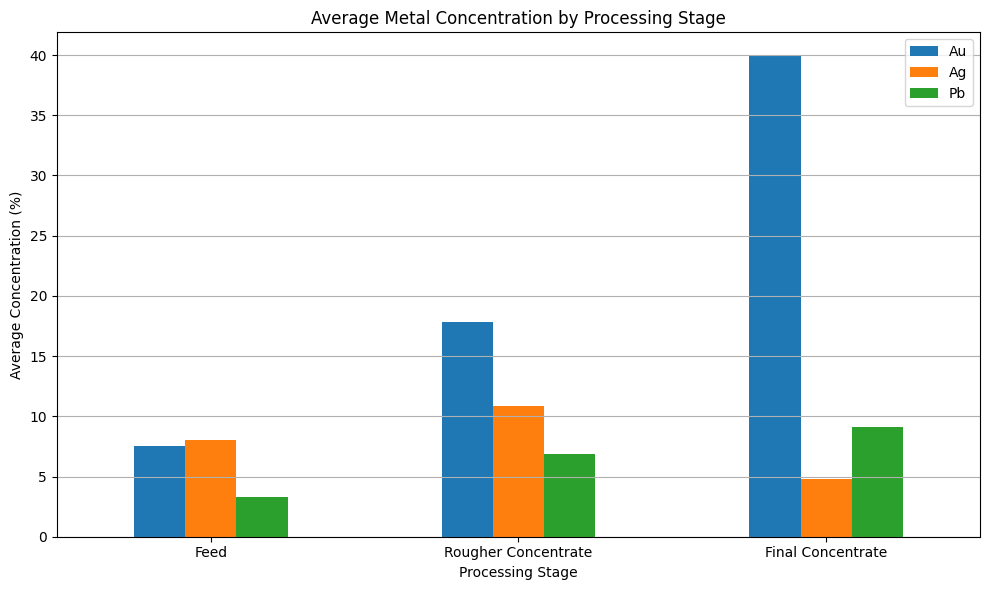

In [14]:
# metal concentration purification stage
metal_columns_by_stage = {
    'Feed': {
        'Au': 'rougher.input.feed_au',
        'Ag': 'rougher.input.feed_ag',
        'Pb': 'rougher.input.feed_pb'
    },
    'Rougher Concentrate': {
        'Au': 'rougher.output.concentrate_au',
        'Ag': 'rougher.output.concentrate_ag',
        'Pb': 'rougher.output.concentrate_pb'
    },
    'Final Concentrate': {
        'Au': 'final.output.concentrate_au',
        'Ag': 'final.output.concentrate_ag',
        'Pb': 'final.output.concentrate_pb'
    }
}

# average concentration for each metal at each stage
concentration_data = {
    metal: [
        df[metal_columns_by_stage[stage][metal]].mean(skipna=True)
        for stage in metal_columns_by_stage
    ]
    for metal in ['Au', 'Ag', 'Pb']
}


concentration_df = pd.DataFrame(concentration_data, index=metal_columns_by_stage.keys())


ax = concentration_df.plot(kind='bar', figsize=(10, 6))
ax.set_title('Average Metal Concentration by Processing Stage')
ax.set_ylabel('Average Concentration (%)')
ax.set_xlabel('Processing Stage')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

The average progression of au concentrate was on target to the process stage improvement we expected.

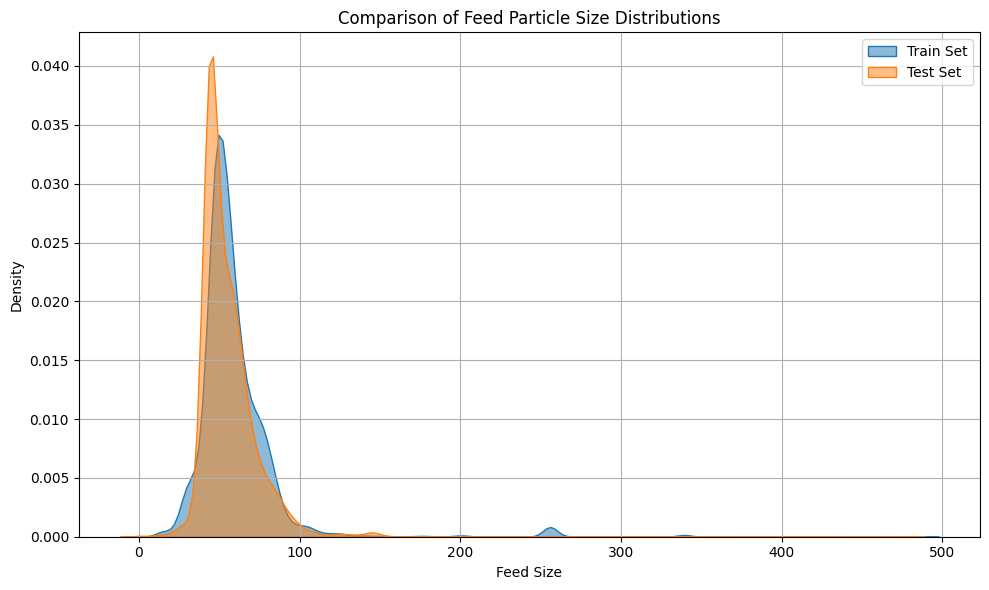

In [15]:
# Column to compare
column = 'rougher.input.feed_size'


train_sizes = df_train[column].dropna()
test_sizes = df_test_wt[column].dropna()


plt.figure(figsize=(10, 6))
sns.kdeplot(train_sizes, label='Train Set', fill=True, alpha=0.5)
sns.kdeplot(test_sizes, label='Test Set', fill=True, alpha=0.5)
plt.title('Comparison of Feed Particle Size Distributions')
plt.xlabel('Feed Size')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The kernel density plot above compares the feed particle size distributions in the training and test datasets. Both distributions are nearly identical in shape, with peaks centered around similar particle size ranges (approximately 50–60 microns) and similar spread. The tails of both distributions extend to larger particle sizes, but this behavior is consistent across both datasets.

There is no significant difference between the training and test set distributions. This similarity ensures that the model trained on the training set will generalize well to the test set without suffering from distribution shift. Therefore, it is valid to use the test set for model evaluation.


<Figure size 1600x1000 with 0 Axes>

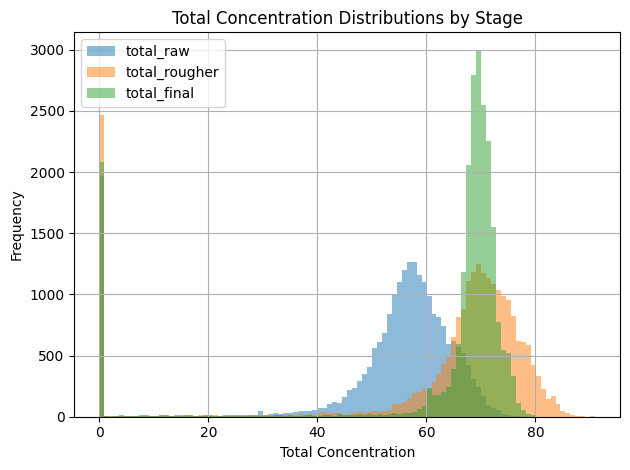

Summary Statistics:
           total_raw  total_rougher   total_final
count  22716.000000   22716.000000  22716.000000
mean      51.856810      61.518427     62.268599
std       17.934564      23.412615     20.860792
min        0.000000       0.000000      0.000000
25%       51.400302      63.325353     67.023260
50%       56.788595      69.414309     69.239194
75%       61.405688      74.025452     71.135495
max       76.978947      90.964431     80.210644
Number of anomalous rows: 0
Remaining samples after removal: 22716


In [16]:
# Define concentration columns by stage
concentration_cols = {
    'raw_feed': ['rougher.input.feed_au', 'rougher.input.feed_ag', 'rougher.input.feed_pb', 'rougher.input.feed_sol'],
    'rougher_concentrate': ['rougher.output.concentrate_au', 'rougher.output.concentrate_ag', 'rougher.output.concentrate_pb', 'rougher.output.concentrate_sol'],
    'final_concentrate': ['final.output.concentrate_au', 'final.output.concentrate_ag', 'final.output.concentrate_pb', 'final.output.concentrate_sol']
}

# Calculate total concentration at each stage
df['total_raw'] = df[concentration_cols['raw_feed']].sum(axis=1, skipna=True)
df['total_rougher'] = df[concentration_cols['rougher_concentrate']].sum(axis=1, skipna=True)
df['total_final'] = df[concentration_cols['final_concentrate']].sum(axis=1, skipna=True)


plt.figure(figsize=(16, 10))
df[['total_raw', 'total_rougher', 'total_final']].plot(kind='hist', bins=100, alpha=0.5)
plt.title('Total Concentration Distributions by Stage')
plt.xlabel('Total Concentration')
plt.grid(True)
plt.tight_layout()
plt.show()


summary_stats = df[['total_raw', 'total_rougher', 'total_final']].describe()
print("Summary Statistics:\n", summary_stats)

# Identify anomalies 
anomaly_mask = (df['total_raw'] > 100) | (df['total_rougher'] > 100) | (df['total_final'] > 100)
print(f"Number of anomalous rows: {anomaly_mask.sum()}")

# Remove anomalies
df_cleaned = df[~anomaly_mask].copy()
print(f"Remaining samples after removal: {len(df_cleaned)}")


The total concentration distributions for the raw feed, rougher concentrate, and final concentrate stages show no abnormal values. All total concentrations fall within physically reasonable limits, with none exceeding 100%. Specifically, the maximum values are approximately 77% for raw feed, 91% for rougher concentrate, and 80% for final concentrate.

Summary statistics indicate consistent and well-distributed values across all stages:
- Mean concentrations range from 51.86% (raw feed) to 62.27% (final concentrate)
- Standard deviations are moderate, reflecting reasonable variation
- No concentration exceeds the physical constraint of 100%
- Although the minimum value is 0.0 for each stage, these entries are rare and do not skew the distribution significantly

No anomalous rows were detected based on the 100% threshold. Therefore, no records were removed from the dataset. The cleaned dataset retains all 22,716 rows, confirming that the data integrity is acceptable for modeling purposes.


## Build Model and Final sMAPE

### sMAPE

In [17]:
#define sMAPE
def smape(y_true, y_pred):
    """
    Calculate Symmetric Mean Absolute Percentage Error (sMAPE).
    """
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    diff = np.abs(y_true - y_pred) / denominator
    return np.mean(diff) * 100

def final_smape(y_true_rougher, y_pred_rougher, y_true_final, y_pred_final):
    """
    Compute the final weighted sMAPE for rougher and final output recovery.
    Weight: 25% for rougher, 75% for final.
    """
    smape_rougher = smape(y_true_rougher, y_pred_rougher)
    smape_final = smape(y_true_final, y_pred_final)
    final_score = 0.25 * smape_rougher + 0.75 * smape_final
    return final_score


#### Learning Curve Function 

In [18]:
def plot_learning_curve_smape_dual(pipeline, train_features, target_rougher, target_final, title_prefix='Learning Curve', cv=5):
    """
    Plots learning curves using sMAPE for both rougher and final targets.
    """
    train_sizes = np.linspace(0.1, 1.0, 5)
    smape_results = {'rougher': {'train': [], 'val': []}, 'final': {'train': [], 'val': []}}

    for frac in train_sizes:
        subset_size = int(frac * len(train_features))
        X_subset = train_features[:subset_size]
        y_rougher_subset = target_rougher[:subset_size]
        y_final_subset = target_final[:subset_size]

        kf = KFold(n_splits=cv, shuffle=True, random_state=42)

        rougher_train_scores, rougher_val_scores = [], []
        final_train_scores, final_val_scores = [], []

        for train_idx, val_idx in kf.split(X_subset):
            X_tr, X_val = X_subset.iloc[train_idx], X_subset.iloc[val_idx]
            y_r_tr, y_r_val = y_rougher_subset.iloc[train_idx], y_rougher_subset.iloc[val_idx]
            y_f_tr, y_f_val = y_final_subset.iloc[train_idx], y_final_subset.iloc[val_idx]

            pipeline.fit(X_tr, y_r_tr)
            y_r_tr_pred = pipeline.predict(X_tr)
            y_r_val_pred = pipeline.predict(X_val)

            pipeline.fit(X_tr, y_f_tr)
            y_f_tr_pred = pipeline.predict(X_tr)
            y_f_val_pred = pipeline.predict(X_val)

            rougher_train_scores.append(smape(y_r_tr, y_r_tr_pred))
            rougher_val_scores.append(smape(y_r_val, y_r_val_pred))
            final_train_scores.append(smape(y_f_tr, y_f_tr_pred))
            final_val_scores.append(smape(y_f_val, y_f_val_pred))

        smape_results['rougher']['train'].append(np.mean(rougher_train_scores))
        smape_results['rougher']['val'].append(np.mean(rougher_val_scores))
        smape_results['final']['train'].append(np.mean(final_train_scores))
        smape_results['final']['val'].append(np.mean(final_val_scores))

    # Plot both
    plt.figure(figsize=(10, 6))
    for target in ['rougher', 'final']:
        plt.plot(train_sizes * len(train_features), smape_results[target]['train'], label=f'{target.capitalize()} Train sMAPE')
        plt.plot(train_sizes * len(train_features), smape_results[target]['val'], linestyle='--', label=f'{target.capitalize()} Validation sMAPE')

    plt.title(f'{title_prefix}: sMAPE vs Training Size')
    plt.xlabel('Training Set Size')
    plt.ylabel('sMAPE (%)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


### Models

#### RandomForest Regressor

In [19]:
# Setup features and targets
features = df_train.drop(['rougher.output.recovery', 'final.output.recovery'], axis=1)
target_rougher = df_train['rougher.output.recovery']
target_final = df_train['final.output.recovery']

# Define pipeline
rf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(random_state=42))
])

# Setup cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=12345)

# Get cross-validated predictions
rougher_preds = cross_val_predict(rf_pipeline, features, target_rougher, cv=kf)
final_preds = cross_val_predict(rf_pipeline, features, target_final, cv=kf)

# Compute final sMAPE 
rf_final_smape_score = final_smape(target_rougher, rougher_preds, target_final, final_preds)

print(f"RandomForest Final sMAPE: {rf_final_smape_score:.4f}")


RandomForest Final sMAPE: 4.5438


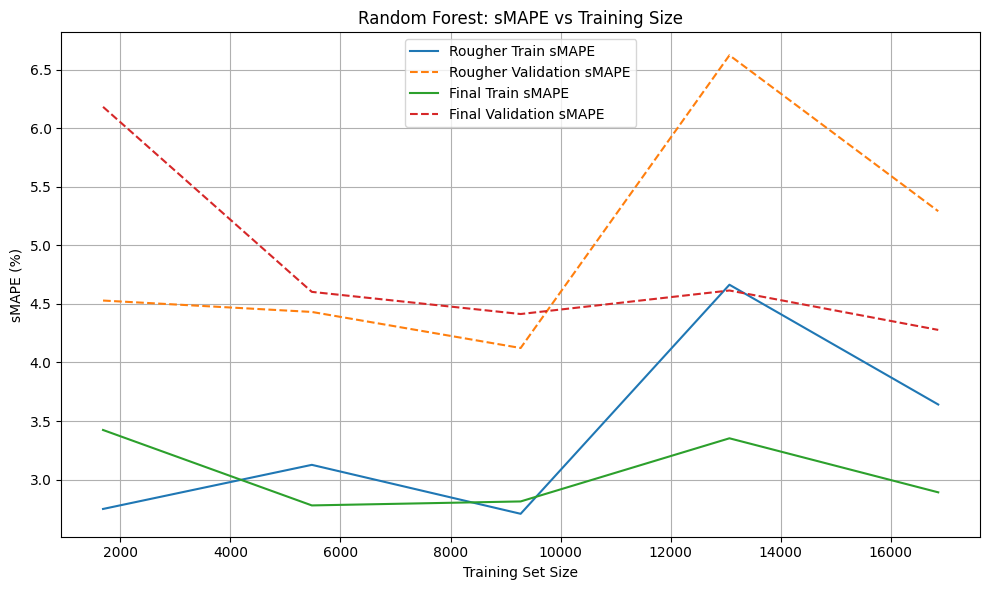

In [20]:
plot_learning_curve_smape_dual(rf_pipeline, features, target_rougher, target_final, title_prefix='Random Forest')


#### Linear Regression

In [21]:

# Linear Regression model pipeline
lr_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

# Get cross-validated predictions
lr_rougher_preds = cross_val_predict(lr_pipeline, features, target_rougher, cv=kf)
lr_final_preds = cross_val_predict(lr_pipeline, features, target_final, cv=kf)

# Compute final sMAPE
lr_final_smape_score = final_smape(target_rougher, lr_rougher_preds, target_final, lr_final_preds)

print(f"Linear Regression Final sMAPE: {lr_final_smape_score:.4f}")


Linear Regression Final sMAPE: 9.9985


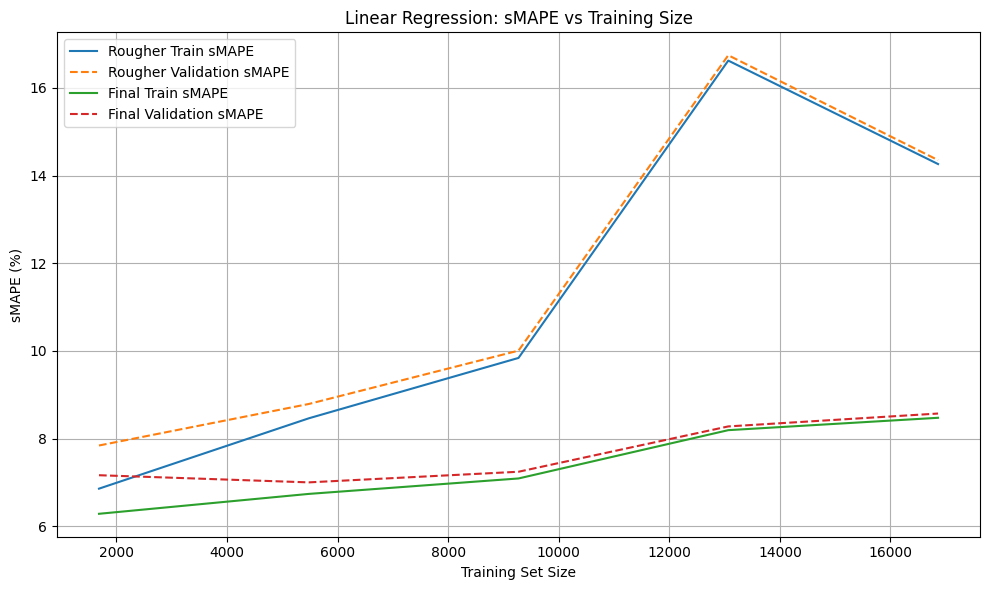

In [22]:
plot_learning_curve_smape_dual(lr_pipeline, features, target_rougher, target_final, title_prefix='Linear Regression')


#### XGBoost

In [23]:
# XGBoost model pipeline
xgb_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('model', XGBRegressor(random_state=42))
])

# Get cross-validated predictions
xgb_rougher_preds = cross_val_predict(xgb_pipeline, features, target_rougher, cv=kf)
xgb_final_preds = cross_val_predict(xgb_pipeline, features, target_final, cv=kf)

# Compute final sMAPE
xgb_final_smape_score = final_smape(target_rougher, xgb_rougher_preds, target_final, xgb_final_preds)

print(f"XGBoost Final sMAPE: {xgb_final_smape_score:.4f}")


XGBoost Final sMAPE: 5.6246


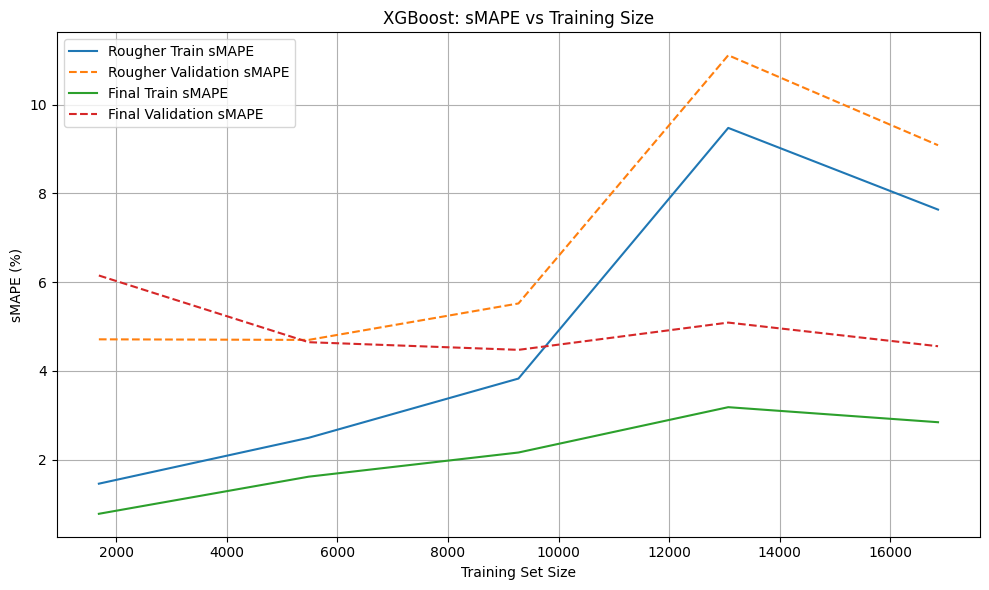

In [24]:
plot_learning_curve_smape_dual(xgb_pipeline, features, target_rougher, target_final, title_prefix='XGBoost')


#### CatBoost

In [25]:
# CatBoost model pipeline
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('model', CatBoostRegressor(verbose=0, random_state=12345))
])

# Get cross-validated predictions
cat_rougher_preds = cross_val_predict(cat_pipeline, features, target_rougher, cv=kf)
cat_final_preds = cross_val_predict(cat_pipeline, features, target_final, cv=kf)

# Compute final sMAPE
cat_final_smape_score = final_smape(target_rougher, cat_rougher_preds, target_final, cat_final_preds)

print(f"CatBoost Final sMAPE: {cat_final_smape_score:.4f}")


CatBoost Final sMAPE: 5.1661


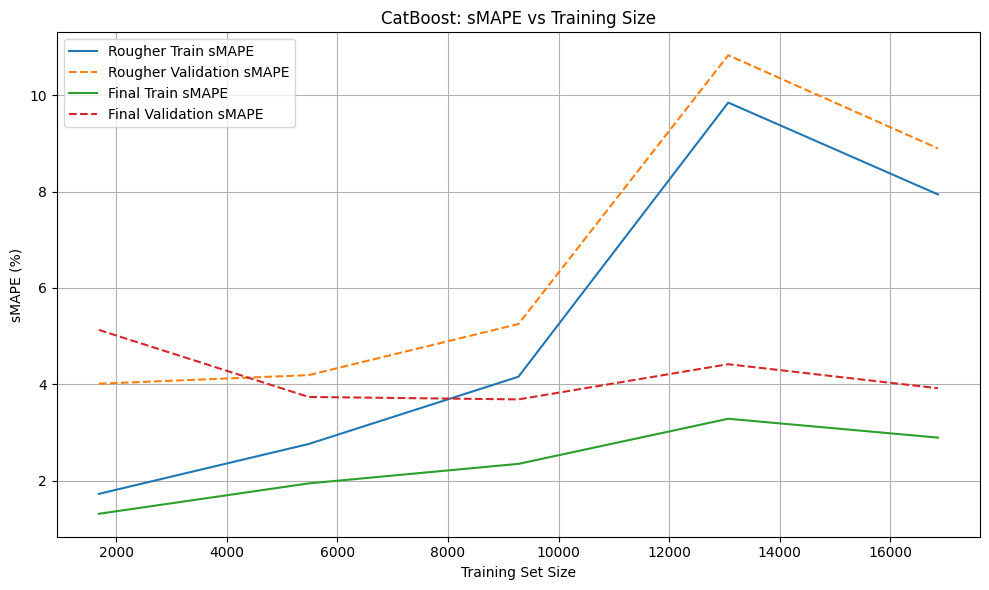

In [26]:
plot_learning_curve_smape_dual(cat_pipeline, features, target_rougher, target_final, title_prefix='CatBoost')


### Model Performance Summary: Final sMAPE Comparison

This summary evaluates four regression models trained to predict gold recovery at two key stages: rougher and final. The evaluation metric used is the Final sMAPE, a weighted score combining both stages (25% rougher, 75% final).

| Model             | Final sMAPE | Summary                                                                 |
|------------------|-------------|-------------------------------------------------------------------------|
| **Random Forest** | **4.5438**  | Best overall performer. Exhibits low error and stable validation trends. |
| **CatBoost**      | 5.1661      | Strong performance, close second. Slight variance in validation curve.   |
| **XGBoost**       | 5.6246      | Solid performance. Slightly higher variance, especially for rougher stage. |
| **Linear Regression** | 9.9985  | Underperforms due to high validation sMAPE. Poor fit for non-linear patterns. |

### Conclusion

- **Random Forest** is the most robust model for predicting gold recovery across both stages.
- **CatBoost** performs comparably and may be favored for efficiency, speed, or certain deployment environments.
- **XGBoost** is a viable alternative but shows more fluctuation in performance.
- **Linear Regression** lacks the complexity to model the process effectively and should be avoided.
---


## Test Set

In [27]:
#Clear and Save Model
joblib.dump(cat_pipeline, 'best_model_cat.joblib')
loaded_cat = joblib.load('best_model_cat.joblib')

joblib.dump(rf_pipeline, 'best_model_rf.joblib')
loaded_rf = joblib.load('best_model_rf.joblib')

### RandomForest

In [28]:

features_test = df_test_wt.drop(['rougher.output.recovery', 'final.output.recovery'], axis=1)
target_rougher_test = df_test_wt['rougher.output.recovery']
target_final_test = df_test_wt['final.output.recovery']

# Get cross-validated predictions
rougher_preds_test = cross_val_predict(loaded_rf, features_test, target_rougher_test, cv=kf)
final_preds_test = cross_val_predict(loaded_rf, features_test, target_final_test, cv=kf)

# Compute final sMAPE 
rf_final_smape_score_test = final_smape(target_rougher_test, rougher_preds_test, target_final_test, final_preds_test)
print(f"Test RandomForest Final sMAPE: {rf_final_smape_score_test:.4f}")


Test RandomForest Final sMAPE: 4.0817


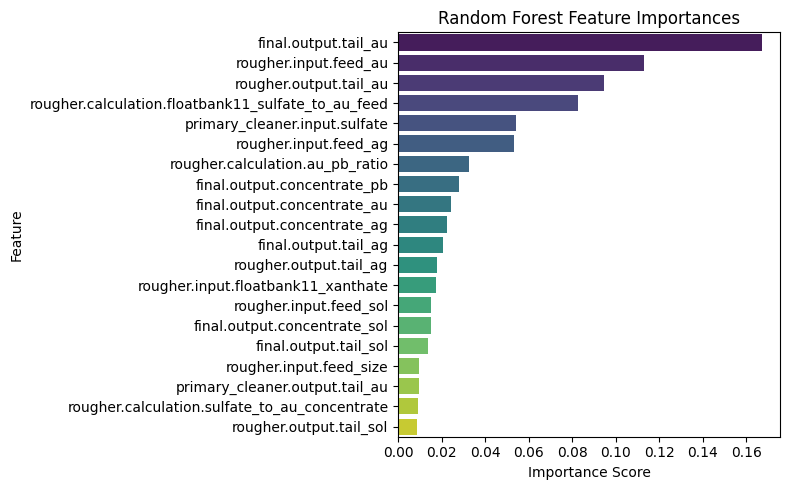

In [29]:

# Create a DataFrame for easier plotting
feature_importance_df = pd.DataFrame({
    'Feature': features_test.columns,
    'Importance': loaded_rf.named_steps['model'].feature_importances_
})

# Sort by importance
rf_feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(20)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(
    data=rf_feature_importance_df,
    x='Importance',
    y='Feature',
    palette='viridis'
)
plt.title("Random Forest Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()



### CatBoost

In [30]:

features_test = df_test_wt.drop(['rougher.output.recovery', 'final.output.recovery'], axis=1)
target_rougher_test = df_test_wt['rougher.output.recovery']
target_final_test = df_test_wt['final.output.recovery']

# Get cross-validated predictions
rougher_preds_test = cross_val_predict(loaded_cat, features_test, target_rougher_test, cv=kf)
final_preds_test = cross_val_predict(loaded_cat, features_test, target_final_test, cv=kf)


rf_final_smape_score_test = final_smape(target_rougher_test, rougher_preds_test, target_final_test, final_preds_test)
print(f"Test CatBoost Regressor Final sMAPE: {rf_final_smape_score_test:.4f}")



Test CatBoost Regressor Final sMAPE: 4.3189


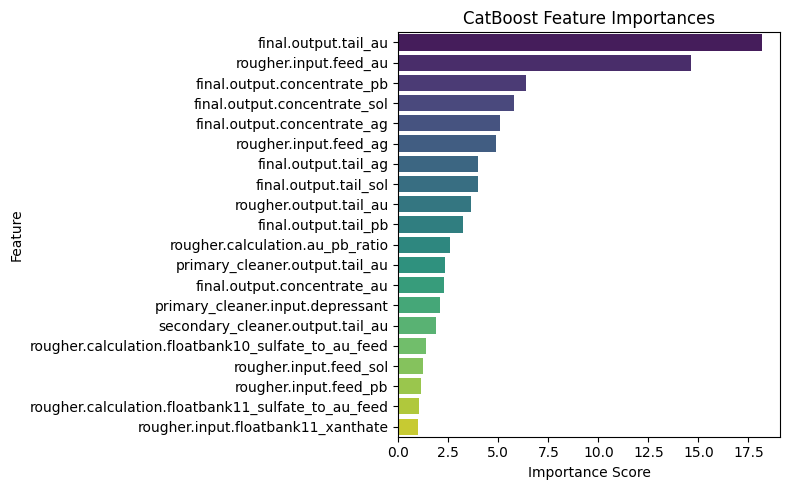

In [31]:
# Create a DataFrame for easier plotting
feature_importance_df = pd.DataFrame({
    'Feature': features_test.columns,
    'Importance': loaded_cat.named_steps['model'].feature_importances_
})

# Sort by importance
cat_feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(20)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(
    data= cat_feature_importance_df,
    x='Importance',
    y='Feature',
    palette='viridis'
)
plt.title("CatBoost Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


### Model Test Set Summary

This summary evaluates two regression models on test data to predict gold recovery at two key stages: rougher and final. The evaluation metric used is the Final sMAPE, a weighted score combining both stages (25% rougher, 75% final).

| Model             | Final sMAPE | Summary                                                                 |
|------------------|-------------|-------------------------------------------------------------------------|
| **Random Forest** | **4.0817**  | Best overall performer. Possible slow production speed |
| **CatBoost**      | 4.3189      | Strong learning improvement, may improve over time.   |


### Conclusion

- **Random Forest** is the most robust model for predicting gold recovery but slower in speed.
- **CatBoost** shows sharp increase in learning and may be better suited for future deployment.
- Almost identical feature importance structure.

---


## Project Summary: Predicting Gold Recovery from Ore Processing

This project focused on developing machine learning models to predict gold recovery at two key stages of the mineral processing pipeline: the rougher stage and the final purification stage. Using historical process data, we built and evaluated multiple regression models to estimate recovery efficiency. The main metric used was Final sMAPE—a weighted symmetric Mean Absolute Percentage Error that prioritizes final recovery (75%) over rougher recovery (25%).

After extensive preprocessing, exploratory data analysis, and feature engineering, we trained and validated four models: Random Forest, CatBoost, XGBoost, and Linear Regression. Random Forest achieved the best results on both cross-validation and test sets, showing the lowest error and most stable performance. CatBoost was a close second and demonstrated strong learning behavior and generalization.

Data integrity was verified through particle size distribution comparison and concentration checks across all stages. No anomalies were found in the total concentrations, and the particle size distributions between training and test sets were nearly identical—confirming a valid and unbiased evaluation environment.

In conclusion, the pipeline provides a reliable and accurate prediction framework for gold recovery, with Random Forest and CatBoost models being the top contenders for deployment.
